 ## 1. IMPORTAR LIBRERIAS Y DATASET

In [1]:
%pip install matplotlib 
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import math as mt
from matplotlib import pyplot as plt
from scipy import stats as st

Como primer paso antes de comenzar a estudiar los datos y cualquier análisis, lo primero a realizar es importar las librerias que nos permitiran llamar a los métodos y funciones que nos permitiran llevar cabo distintos procesos.

In [3]:
df_ice = pd.read_csv('c:/Users/PC/Proyecto_sprint_06_Tienda_videojuegos_online_ICE/games.csv')
df_ice.info(show_counts=True)
print(df_ice.columns)
print('Hay tantas(filas y columnas)=', df_ice.shape)
df_ice.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')
Hay tantas(filas y columnas)= (16715, 11)


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Con este primer vistazo al dataframe proporcionado por Ice, podemos encontrar que esta conformado por 11 columnas que incluyen el nombre del juego, plataforma año de lanzamiento, ventas en distintas regiones, la puntiación de la crítica, puntuación por usuarios y la clasificación del juego. Las columnas parecen estar ordenadas y con el conocido sanke case pero tienen mayúsculas y minúsculas así que sería recomendable ponerlas solo en minúsculas. Al hacer una revisión rápida de los vlaores  dentro del dataframe vemos que algunas columnas sus valores no conucerdan como en el caso de User_Score que debería o sería mucho mejor tenerlos como valores flotantes y son objects etc.

## 2. PREPARACION DE DATOS

In [4]:
df_ice_new_columns = []
for column in df_ice.columns:
    name_lowered = column.lower()
    df_ice_new_columns.append(name_lowered)
df_ice.columns = df_ice_new_columns
print(df_ice.columns)
df_ice.head()

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


En estas líneas de código se han cambiado los valores de la columna year_of_release de tipo float por entero y de la columna user_score de object a float, al hacer esto en dicha columna ahora la cantidad de valores no nulos se ha incrementado esto pudó ser porque de seguro hay celdas del dataframe que se rellenaron con espacios o cadenas vacias. Ahora que nuestros datos ya estan en los tipos que necesitamos y arreglamos el nombre de las columnas comenzamos a buscar duplicados dentro del dataframe.

## 3. BUSQUEDA DE DUPLICADOS

In [5]:
print('Hay ', df_ice.duplicated().sum(), 'filas completas duplicadas' )
print('Hay ', df_ice['name'].duplicated().sum(), 'títulos duplicados')
print('Hay ', df_ice['name'].nunique(), 'títulos únicos')
df_ice.info()
df_ice.head(10)

Hay  0 filas completas duplicadas
Hay  5155 títulos duplicados
Hay  11559 títulos únicos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


Como es lógico lo sugiuente es buscar duplicados, al indagar en el dataframe vemos que no hay filas completamente duplicadas por loq ue sabemos que no hay duplciados explícitos y al revisar solo la columna name si encontramos mas de 5000 nombres repetiods pero no los podemos considerar como duplicados implícitos ya que hay que recordar que hay títulos que se lanzarón para varias consolas y plataformas.

## 4. VALORES AUSENTES

In [6]:
print('En la columna del año de lanzamiento hay', df_ice['year_of_release'].isna().sum(), 'valores ausentes')
print('En la columna de la crítica hay', df_ice['critic_score'].isna().sum(), 'valores ausentes')
print('En la columna de score por usuarios hay', df_ice['user_score'].isna().sum(), 'valores ausentes')
print('En la columna del rating hay', df_ice['rating'].isna().sum(), 'valores ausentes')

En la columna del año de lanzamiento hay 269 valores ausentes
En la columna de la crítica hay 8578 valores ausentes
En la columna de score por usuarios hay 6701 valores ausentes
En la columna del rating hay 6766 valores ausentes


In [7]:
df_ice['rating'].unique()
df_ice['rating'].fillna('TBD', inplace=True)
df_ice['rating'].isna().sum()
df_ice.head()

C:\Users\PC\AppData\Local\Temp\ipykernel_37040\3374638883.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ice['rating'].fillna('TBD', inplace=True)


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,TBD
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,TBD


En la columna rating donde se proporciona la calificación de la ESRB tambiémn hay bastantes valores ausentes asi que hemos decidido rellenar estos valores con TBD(to be determinated), al igual que en las otras columnas con valores ausentes puede haber distintos factores pero los que más datos ausentes presentan son aquellos con las ventas mas bajas y esto es algo normal son los juegos que menso llaman la atención.

In [8]:
t_sales = df_ice['na_sales'] + df_ice['eu_sales'] + df_ice['jp_sales'] + df_ice['other_sales']
df_ice.insert(8, 'total_sales', t_sales)
df_ice.info()
df_ice.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   total_sales      16715 non-null  float64
 9   critic_score     8137 non-null   float64
 10  user_score       10014 non-null  object 
 11  rating           16715 non-null  object 
dtypes: float64(7), object(5)
memory usage: 1.5+ MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,82.54,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,40.24,NaN,NaN,TBD
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,35.52,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,32.77,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,31.38,NaN,NaN,TBD


## 5. ANALISIS DE DATOS

    year_of_release  name
0            1980.0     9
1            1981.0    46
2            1982.0    36
3            1983.0    17
4            1984.0    14
5            1985.0    14
6            1986.0    21
7            1987.0    16
8            1988.0    15
9            1989.0    17
10           1990.0    16
11           1991.0    41
12           1992.0    43
13           1993.0    60
14           1994.0   121
15           1995.0   219
16           1996.0   263
17           1997.0   289
18           1998.0   379
19           1999.0   338
20           2000.0   350
21           2001.0   482
22           2002.0   829
23           2003.0   775
24           2004.0   762
25           2005.0   939
26           2006.0  1006
27           2007.0  1197
28           2008.0  1427
29           2009.0  1426
30           2010.0  1255
31           2011.0  1136
32           2012.0   653
33           2013.0   544
34           2014.0   581
35           2015.0   606
36           2016.0   502


<Axes: title={'center': 'Lanzamientos por año'}, xlabel='year_of_release'>

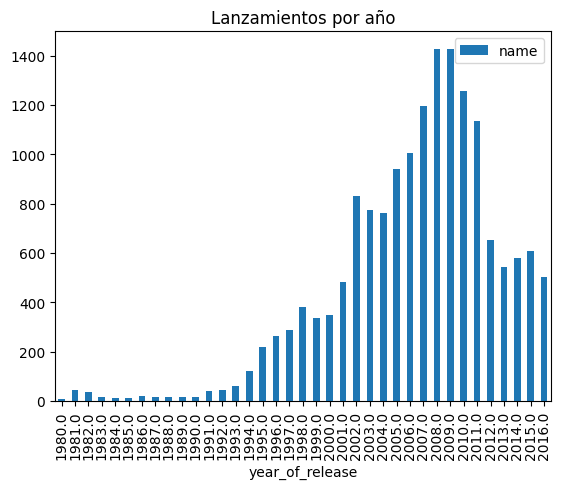

In [9]:
df_games_per_year = df_ice.groupby('year_of_release')['name'].count().reset_index()
print(df_games_per_year)
df_games_per_year.plot(x='year_of_release', kind='bar', title='Lanzamientos por año')

Lo primero a realizar es verificar cuantos juegos se lanzarón por año y tanto en al lista como en el gráfico es fácilo bservar que desde el año 1980 hasta 1993 el registro de Ice tiene muy pocos lanzamientos pero despúes el incremmento comienza a ser bastante considerable hasta los años 2007 y 2008 donde se ve la mayor cantidad de juegos lanzados despúes hay uan disminucíon. Los valores si son altamente significativos entre ciertos periodos uno con respecto del otro es decir; las decad delos ochenta es muy pequeña en comparación con las decada de los 2000.

   platform  total_sales
0       PS2      1255.77
1      X360       971.42
2       PS3       939.65
3       Wii       907.51
4        DS       806.12
5        PS       730.86
6       GBA       317.85
7       PS4       314.14
8       PSP       294.05
9        PC       259.52
10      3DS       259.00
11       XB       257.74
12       GB       255.46
13      NES       251.05
14      N64       218.68
15     SNES       200.04
16       GC       198.93
17     XOne       159.32
18     2600        96.98
19     WiiU        82.19
20      PSV        54.07
21      SAT        33.59
22      GEN        30.77
23       DC        15.95
24      SCD         1.86
25       NG         1.44
26       WS         1.42
27     TG16         0.16
28      3DO         0.10
29       GG         0.04
30     PCFX         0.03


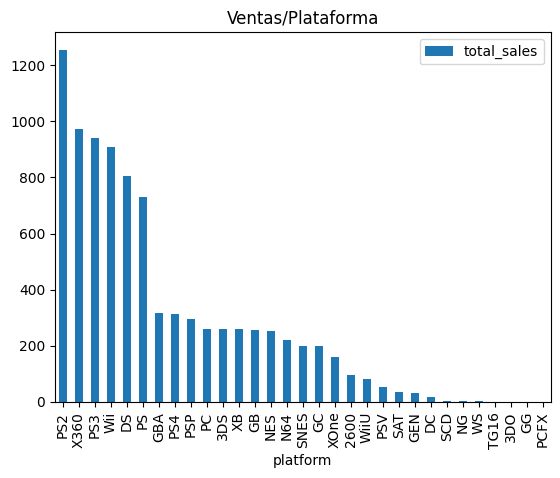

In [10]:
df_sales_per_platform = df_ice.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index()
print(df_sales_per_platform)
df_sales_per_platform = df_ice.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index().plot(x='platform', kind='bar', title='Ventas/Plataforma')

Estas son las plataformas con mas ventas: 
    index platform  total_sales
0      4       DS       806.12
1     15       PS       730.86
2     16      PS2      1255.77
3     17      PS3       939.65
4     26      Wii       907.51
5     28     X360       971.42


<Axes: title={'center': 'Ventas/años'}, ylabel='Frequency'>

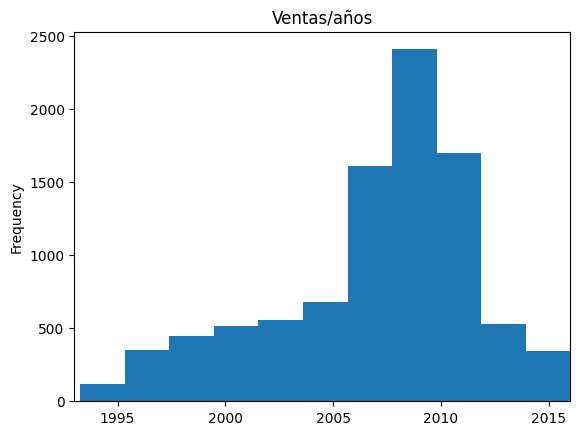

In [11]:
df_sales_per_platform_1 = df_ice.groupby('platform')['total_sales'].sum().reset_index()
df_sales_per_platform_1 = df_sales_per_platform_1[(df_sales_per_platform_1['total_sales'] > 700)].reset_index()
print('Estas son las plataformas con mas ventas: \n', df_sales_per_platform_1)
df_filtered_1 = df_ice[['platform', 'year_of_release']]
df_merged_1 = df_filtered_1.merge(df_sales_per_platform_1, on='platform')
df_merged_1['year_of_release'].plot(kind='hist', bins=15, title='Ventas/años', xlim=[1993, 2016])


In [12]:
def platforms_per_decade(df_ppd, year_1, year_2):
    filtered_ppd = df_ppd[(df_ppd['year_of_release'] >= year_1) & (df_ppd['year_of_release'] <= year_2)]
    unique_platforms = filtered_ppd['platform'].unique()
    return unique_platforms
platforms_80s = platforms_per_decade(df_ice, 1980, 1989)
platforms_90s = platforms_per_decade(df_ice, 1990, 1999)        
platforms_2000s = platforms_per_decade(df_ice, 2000, 2009)
platforms_2010s = platforms_per_decade(df_ice, 2010, 2016)
print("Plataformas en los 80s:", platforms_80s)
print("Plataformas en los 90s:", platforms_90s)
print("Plataformas en los 2000s:", platforms_2000s)
print("Plataformas en los 2010s:", platforms_2010s)

Plataformas en los 80s: ['NES' 'GB' '2600' 'PC' 'DS']
Plataformas en los 90s: ['GB' 'SNES' 'N64' 'PS' 'GEN' 'PC' 'NES' 'DC' 'SAT' 'SCD' 'WS' 'NG' 'TG16'
 '3DO' 'GG' 'PCFX']
Plataformas en los 2000s: ['Wii' 'DS' 'PS2' 'GBA' 'X360' 'PS3' 'XB' 'PC' 'PSP' 'GC' 'GB' 'PS' 'N64'
 'DC' 'WS']
Plataformas en los 2010s: ['X360' 'PS3' 'DS' 'PS4' '3DS' 'Wii' 'XOne' 'WiiU' 'PC' 'PSP' 'PSV' 'PS2']


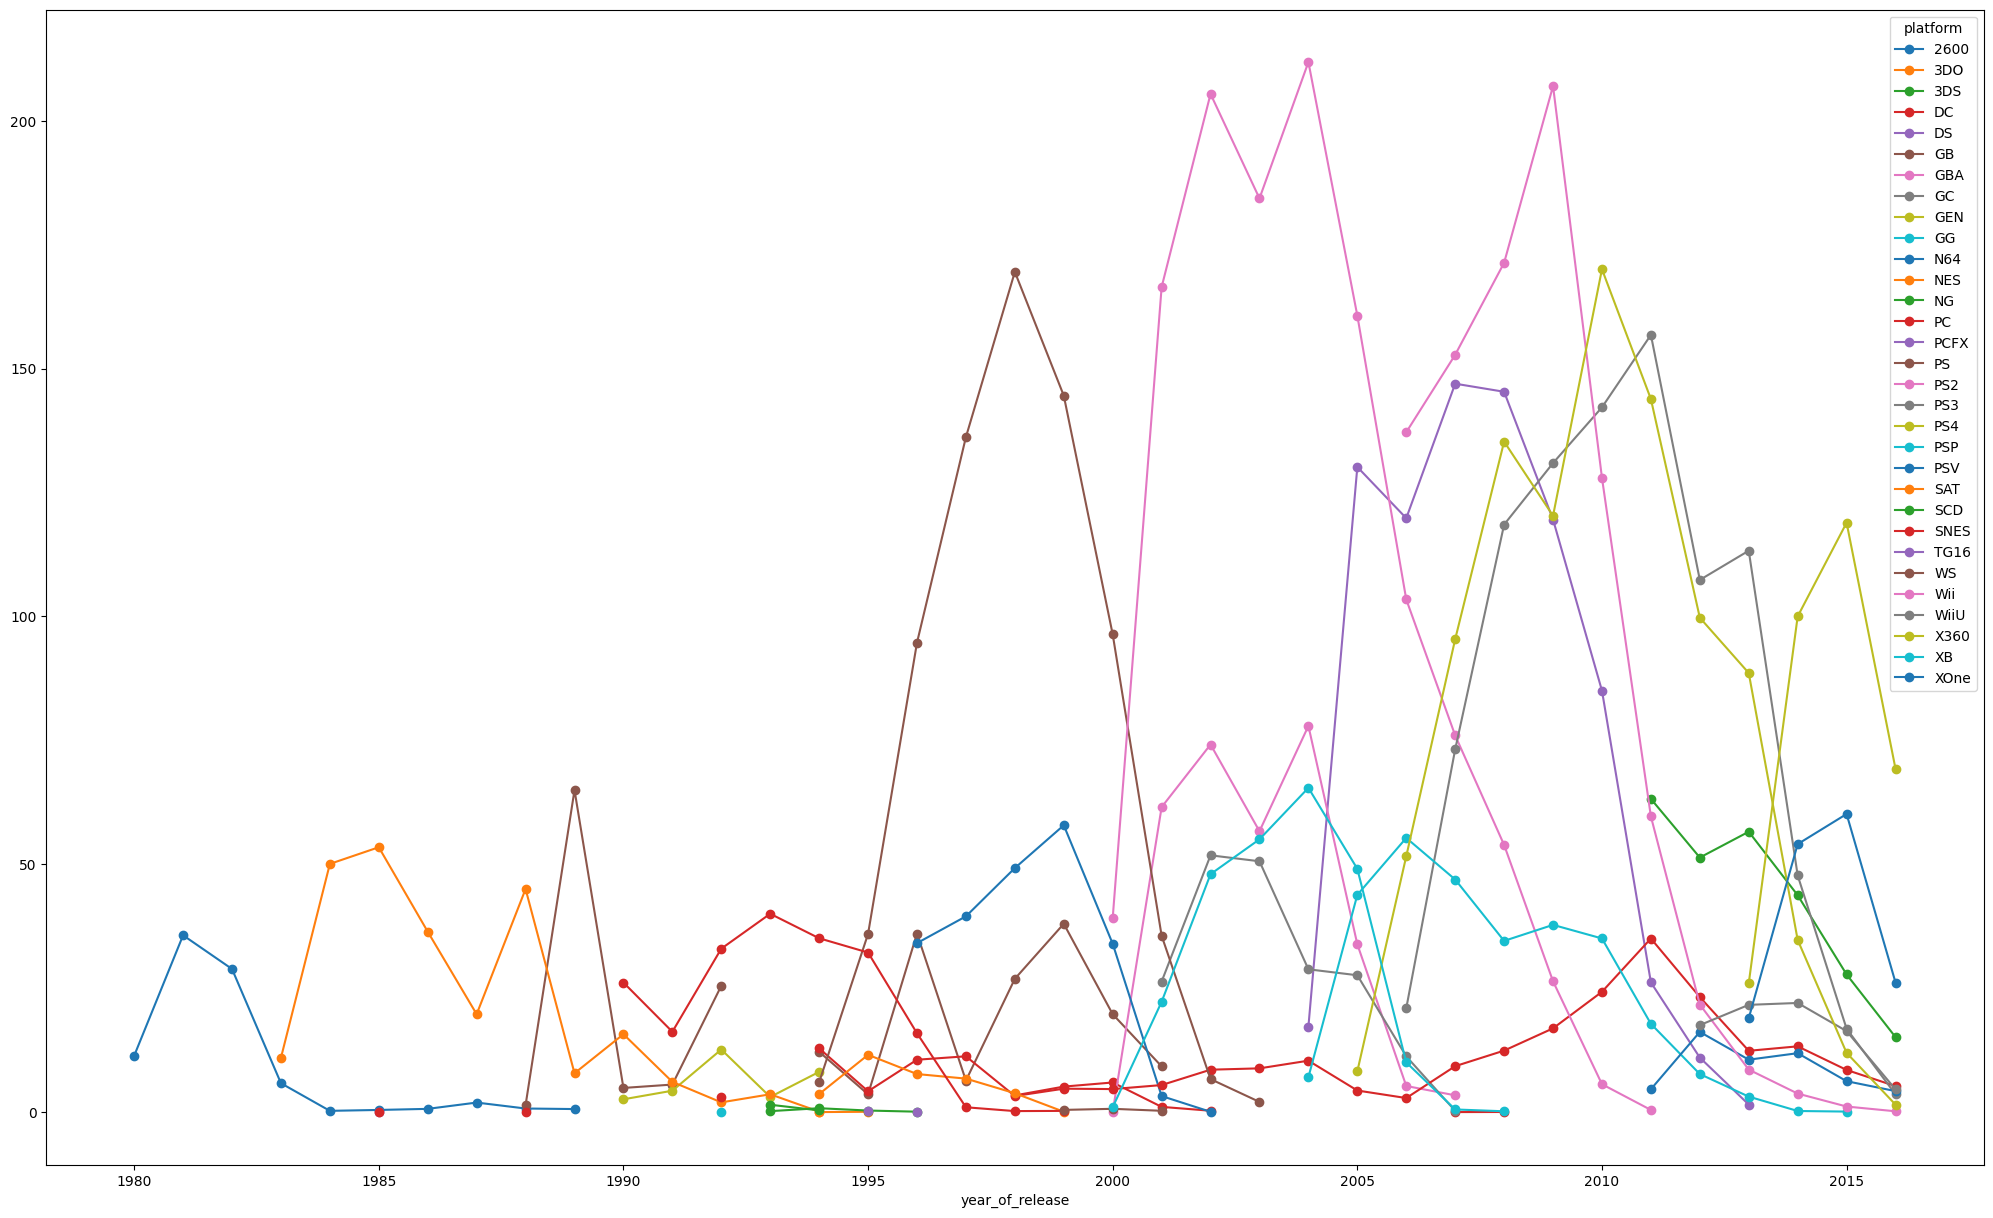

In [13]:
df_pivot = df_ice.pivot_table(index='year_of_release',
                              columns='platform',
                              values='total_sales',
                              aggfunc='sum'
                             ).reset_index()
df_pivot.plot(x='year_of_release', figsize=[25,15], style='-o')
plt.show()

Continuando con el análisis del dataset proporcionado por Ice, lo primero que encontramos con respecto a las ventas de todas las regiones a lo largo del tiempo por plataforma es que las cinco plataformas con mayores ventas son: ps2, x360, Ps3, Wii, Ds.
También se pude concluir con el histograma general, las listas de juegos por décadas y el grafico de dispersión de las plataformas a través del tiempo que hay plataformas que en los 80 y 90 eran populares como el caso de Nes, GB, SNES y otras mas que ya no están vigentes en la actualidad y otras como PC que desde los ochentas hasta hoy aunque no está en los líderes de ventas pero si que se ha mantenido vigente a lo largo del tiempo, otras como  PS2 que es la plataforma que tiene mayores ventas a lo largo de una década. Cabe mencionar que las mayoría de plataformas de en general de acuerdo al grafico de dispersión tienen una vigencia de aproximadamente 10 años como la plataforma 2600 que estubo muy presente en los 80´s y hoy no existe mas, en al actualidad PS4.
Pero al final a partir del 2013 al 2016 hay un decremento general de las plataformas y sus ventas.

                                         name platform  year_of_release  \
31                  Call of Duty: Black Ops 3      PS4           2015.0   
42                         Grand Theft Auto V      PS4           2014.0   
47  Pokemon Omega Ruby/Pokemon Alpha Sapphire      3DS           2014.0   
77                                    FIFA 16      PS4           2015.0   
87               Star Wars Battlefront (2015)      PS4           2015.0   

           genre  na_sales  eu_sales  jp_sales  other_sales  total_sales  \
31       Shooter      6.03      5.86      0.36         2.38        14.63   
42        Action      3.96      6.31      0.38         1.97        12.62   
47  Role-Playing      4.35      3.49      3.10         0.74        11.68   
77        Sports      1.12      6.12      0.06         1.28         8.58   
87       Shooter      2.99      3.49      0.22         1.28         7.98   

    critic_score user_score rating  
31           NaN        NaN    TBD  
42          97.0  

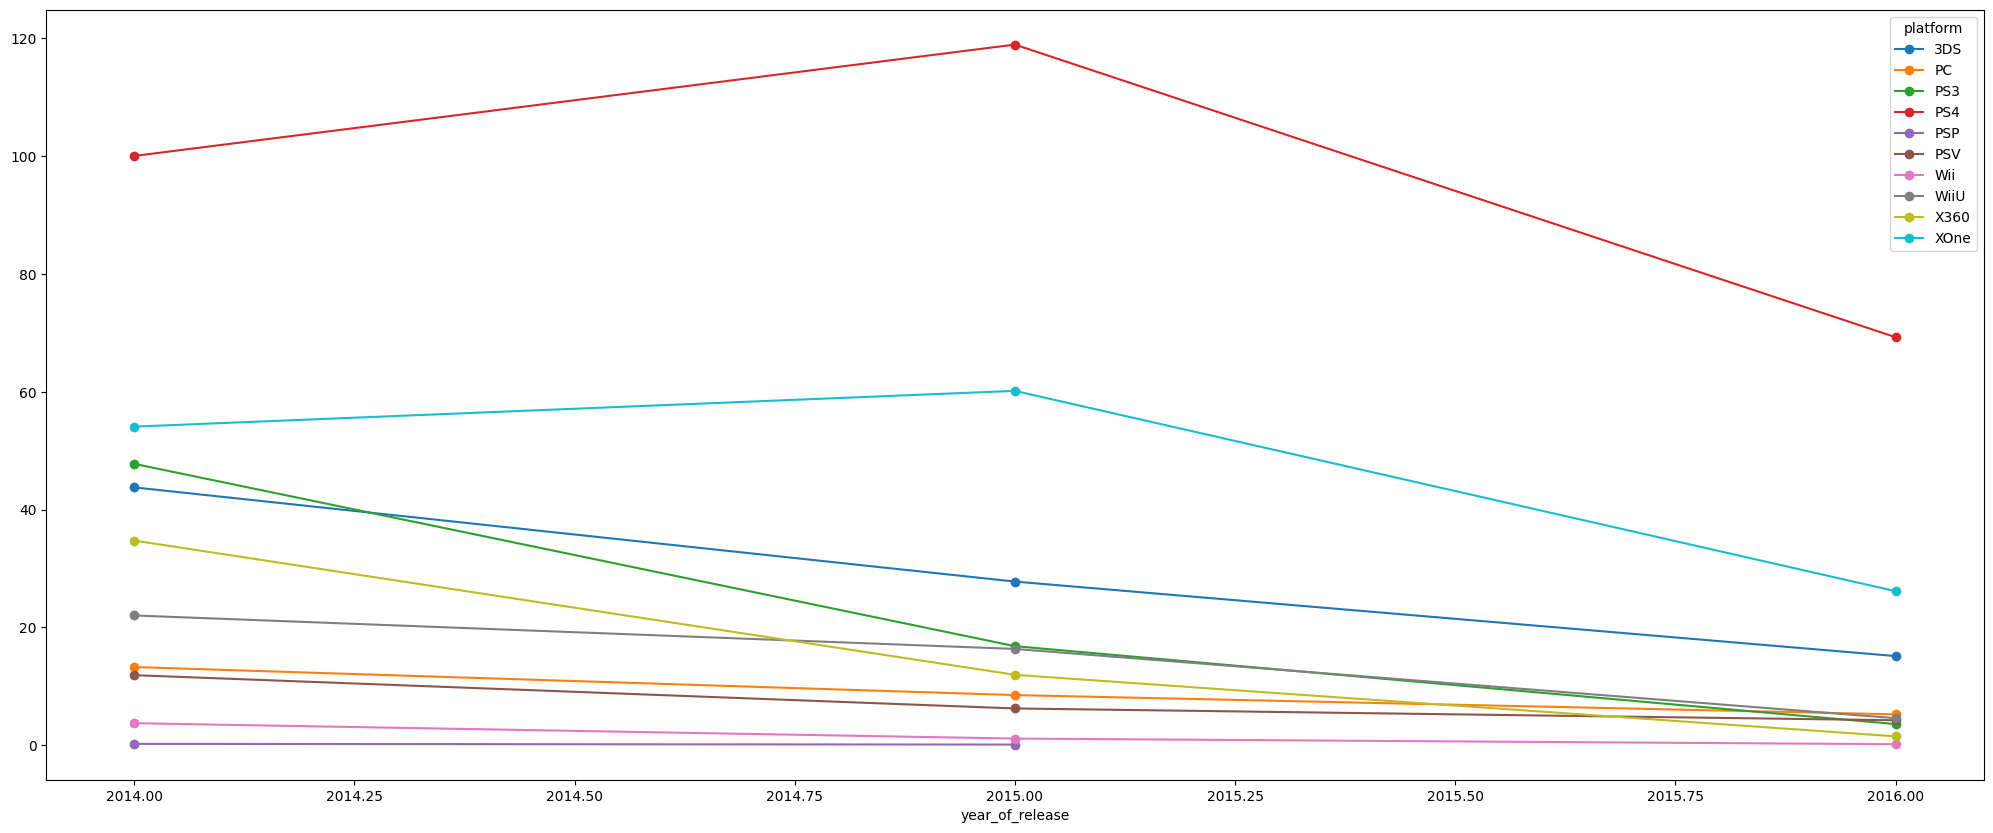

In [14]:
df_pivot_1 = df_ice[(df_ice['year_of_release'] >= 2014)]
print(df_pivot_1.head())
df_pivot_1 = df_pivot_1.pivot_table(index='year_of_release',
                              columns='platform',
                              values='total_sales',
                              aggfunc='sum'
                             ).reset_index()
df_pivot_1.plot(x='year_of_release', figsize=[25,10], style='-o')
plt.show()

Con este gráfico de los últimos dos años podemso observar la tendencia para realizar uns estrategia para eñl año 2017

C:\Users\PC\AppData\Local\Temp\ipykernel_37040\2041919226.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df_ps4, df_ps3, df_xone, df_x360, df_pc], labels=['PS4', 'PS3', 'XONE', 'X360', 'PC'], showfliers=False)


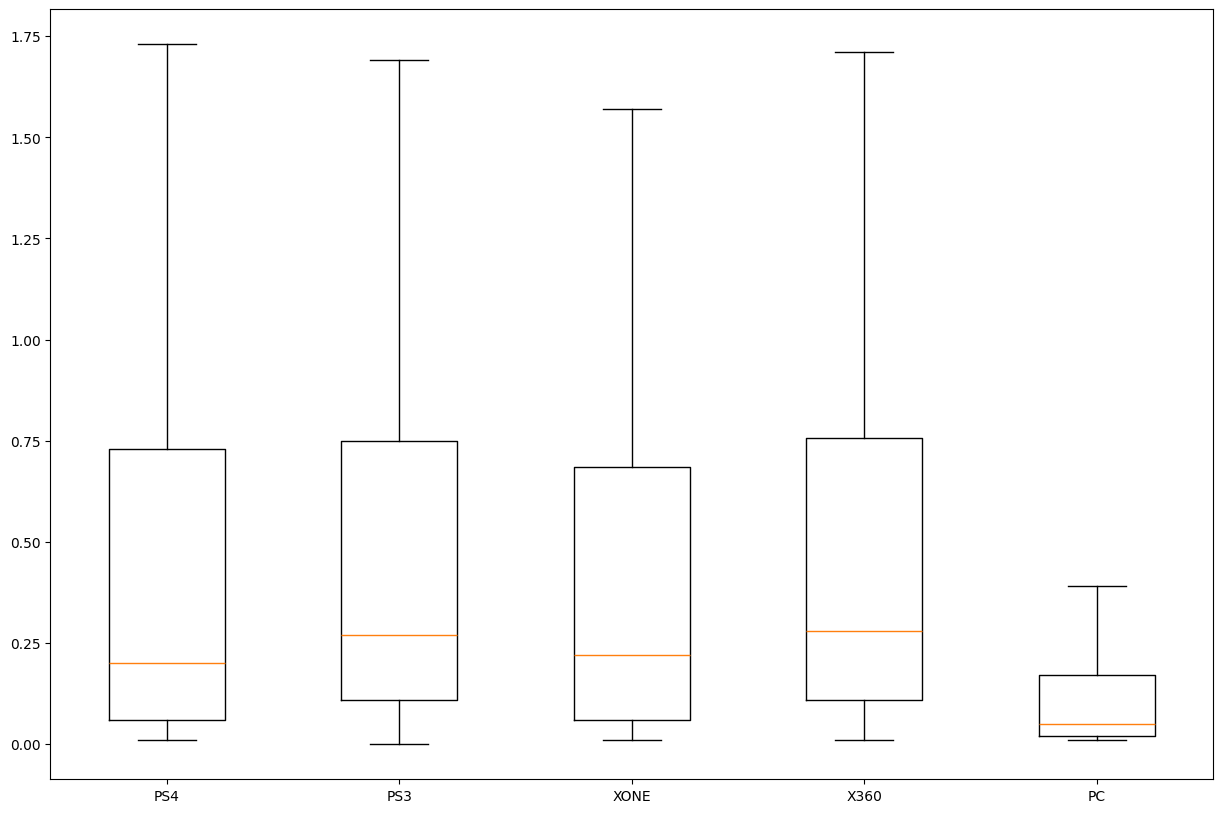

In [15]:
df_ps4 = df_ice[(df_ice['platform'] == 'PS4')]
df_ps4 = df_ps4['total_sales']
df_ps3 = df_ice[(df_ice['platform'] == 'PS3')]
df_ps3 = df_ps3['total_sales']
df_xone = df_ice[(df_ice['platform'] == 'XOne')]
df_xone = df_xone['total_sales']
df_x360 = df_ice[(df_ice['platform'] == 'X360')]
df_x360 = df_x360['total_sales']
df_pc = df_ice[(df_ice['platform'] == 'PC')]
df_pc= df_pc['total_sales']
fig, ax = plt.subplots(figsize=[15, 10])
ax.boxplot([df_ps4, df_ps3, df_xone, df_x360, df_pc], labels=['PS4', 'PS3', 'XONE', 'X360', 'PC'], showfliers=False)
plt.show()

Con las plataformas elegidas o ques epiensa puden ser rentables aún en la actualidad debido a las grandes ventas y la vigencia de algunas de ellas se procedió a hacer unos diagramas de caja de las plataformas PS4, PS3, Xone, X360 y PC; al hacer la comparativa enocntramos que los promedios entre ellas algunos son muy similares, hablamos de las plataformas PS4, PS3, X360 mientras que Xone esta por encima de las otras 4 y PC por debajo pero recordemos que PC se eligió ya que es una platforma con vigencia constante.

       total_sales  critic_score user_score
99            7.39           NaN        NaN
165           5.47          97.0        7.9
179           5.26          81.0        5.4
242           4.49          84.0        6.4
270           4.22          88.0        6.2
...            ...           ...        ...
16630         0.01          63.0        8.2
16643         0.01           NaN        6.6
16645         0.01           NaN        NaN
16660         0.01          74.0        6.7
16672         0.01           NaN        tbd

[247 rows x 3 columns]


La correlación entre las ventas y la crïtica tienen una correlación=  0.41699832800840153


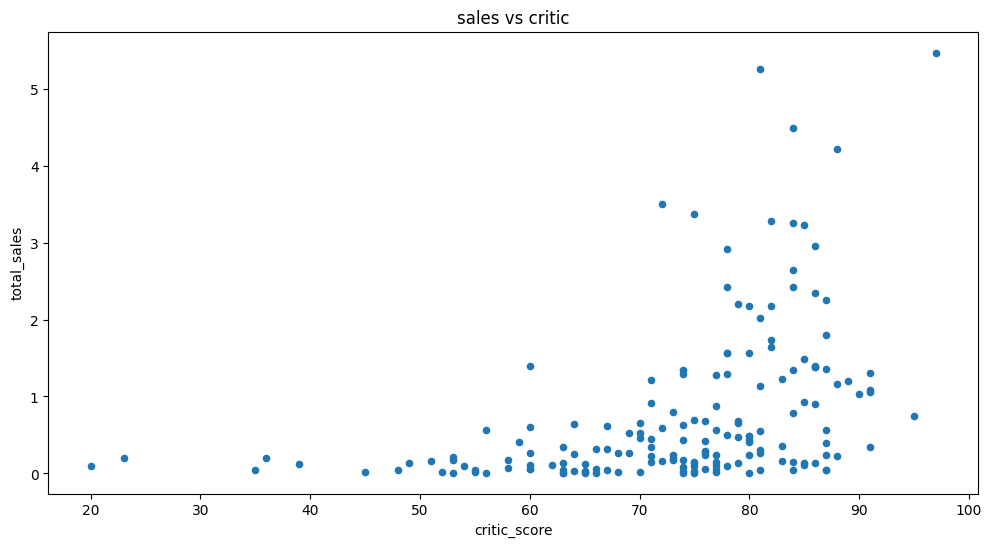

In [16]:
df_xone_score = df_ice[(df_ice['platform'] == 'XOne')]
df_xone_score = df_xone_score[['total_sales', 'critic_score', 'user_score']]
print(df_xone_score)
df_xone_score.plot(kind='scatter', title='sales vs critic', x='critic_score', y='total_sales', figsize=[12, 6])
correlacion_sales_critic_score = df_xone_score['total_sales'].corr(df_xone_score['critic_score'])
print('La correlación entre las ventas y la crïtica tienen una correlación= ', correlacion_sales_critic_score)


La correlación entre las ventas y el score por usuarios tienen una correlación=  -0.06892505328279418


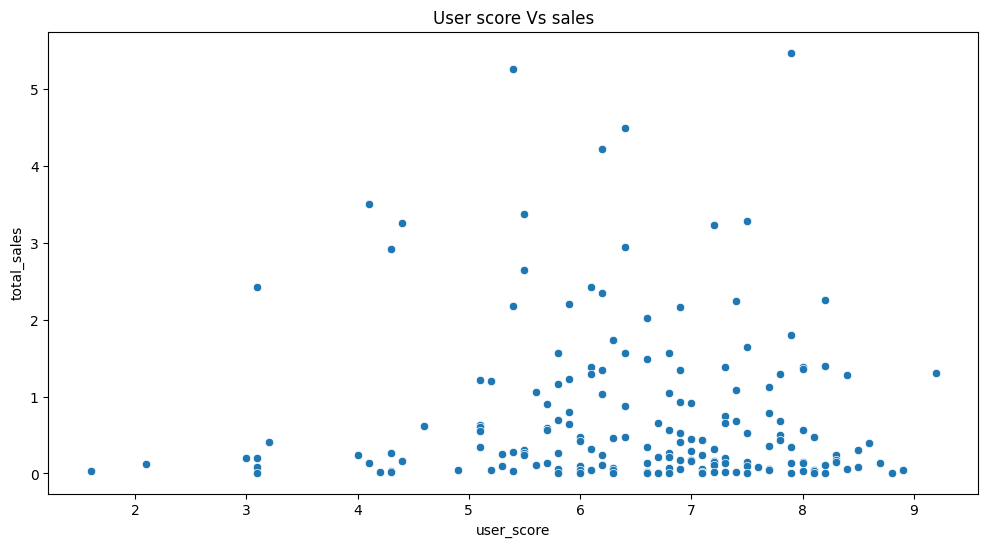

In [17]:
df_xone_score['user_score'] = pd.to_numeric(df_xone_score['user_score'], errors='coerce')
correlacion_sales_user_score = df_xone_score['total_sales'].corr(df_xone_score['user_score'])
print('La correlación entre las ventas y el score por usuarios tienen una correlación= ', correlacion_sales_user_score)
plt.figure(figsize=[12, 6])
sns.scatterplot(x='user_score', y='total_sales', data=df_xone_score)
plt.title('User score Vs sales')
plt.show()

Aquí elegimos a la platforma Xone para realizar un diagrama de disperción y observar la correlación entre las ventas de los juegos de dicah platforma y las calificaciones de la crítica y los usuarios y nos topamso con que si que hay cierta relación entre las ventas mas altas y la calificación por parte de la crítica msa altas pero después no parece ahber una verdadera correlación por eso el resultado es apenas de 0.36 y claramente la calificación por usuarios no presenta ninguan correlación.

Estas son las plataformas que tienen los mimos títulos que XONE: 
 ['PS3' 'X360' 'PS4' 'PC' 'Wii' 'PSV' 'GC' 'WiiU' '3DS' 'PSP' 'DS']
   platform  total_sales
5       PS4       256.35
4       PS3       128.25
10     X360       127.02
3        PC        33.21
9      WiiU        12.40
8       Wii        11.45
7       PSV         6.03
0       3DS         5.11
2        GC         1.30
6       PSP         1.11
1        DS         0.38


<Axes: xlabel='platform'>

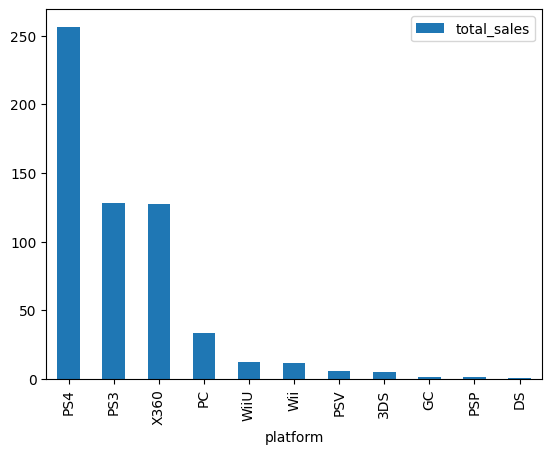

In [18]:
df_xone_score = df_ice[(df_ice['platform'] == 'XOne')]
name_search = df_xone_score['name']
df_no_xone_score = df_ice[(df_ice['platform'] != 'XOne')]
df_names =  df_no_xone_score[df_no_xone_score['name'].isin(name_search)]
print('Estas son las plataformas que tienen los mimos títulos que XONE: \n', df_names['platform'].unique())
df_names = df_names.groupby('platform')['total_sales'].sum().reset_index()
print(df_names.sort_values(by='total_sales', ascending=False))
df_names.sort_values(by='total_sales', ascending=False).plot(kind='bar', x='platform', y='total_sales')

Se han buscado los títulos de XONE en otras plataformas para ver sus ventas y el gráfico nso deja ver que PS4, PS3 y X360 son las plataformas que compiten de manera directa ya que son las que más ventas tienen. Además qeu son las plataformas junto con XOne vigentes en al actualidad.

           genre  total_sales
0         Action      1744.17
10        Sports      1331.27
8        Shooter      1052.45
7   Role-Playing       934.56
4       Platform       827.77
3           Misc       802.51
6         Racing       728.67
2       Fighting       447.53
9     Simulation       389.97
5         Puzzle       242.57
1      Adventure       237.59
11      Strategy       174.23


<Axes: ylabel='Frequency'>

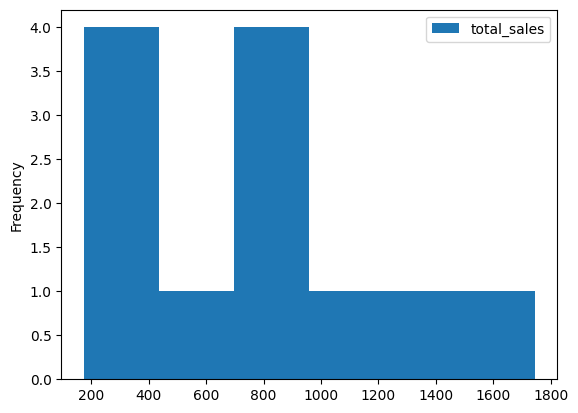

In [19]:
df_by_genre = df_ice.groupby('genre')['total_sales'].sum().reset_index().sort_values(by='total_sales', ascending=False)
print(df_by_genre)
df_by_genre.plot(kind='hist', bins=6)

           genre  total_sales
4       Platform     0.932173
8        Shooter     0.795503
7   Role-Playing     0.623872
6         Racing     0.583403
10        Sports     0.566980
2       Fighting     0.527126
0         Action     0.517711
3           Misc     0.458577
9     Simulation     0.446701
5         Puzzle     0.418224
11      Strategy     0.255095
1      Adventure     0.182341


<Axes: ylabel='Frequency'>

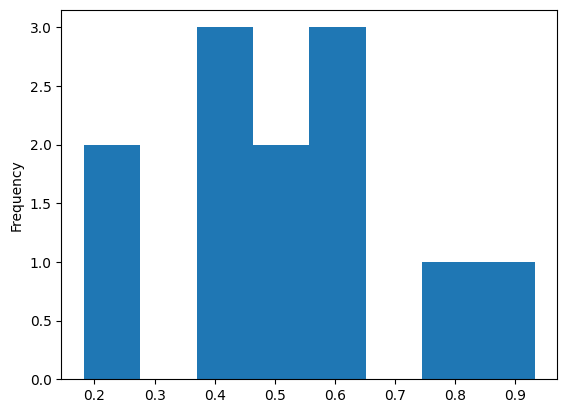

In [20]:
df_by_genre_1 = df_ice.groupby('genre')['total_sales'].mean().reset_index().sort_values(by='total_sales', ascending=False)
print(df_by_genre_1)
df_by_genre_1.plot(kind='hist', bins=8, legend=False)


## 6. PERFILES DE USUARIOS POR REGION

Estas son las 5 plataformas líderes en Norte América: 
    platform  na_sales
28     X360    602.47
16      PS2    583.84
26      Wii    496.90
17      PS3    393.49
4        DS    382.40
Estas son las 5 plataformas líderes en Europa: 
    platform  eu_sales
16      PS2    339.29
17      PS3    330.29
28     X360    270.76
26      Wii    262.21
15       PS    213.61
Estas son las 5 plataformas líderes en Japón: 
    platform  jp_sales
4        DS    175.57
15       PS    139.82
16      PS2    139.20
23     SNES    116.55
2       3DS    100.67


<Axes: title={'center': 'ventas/región'}, xlabel='platform'>

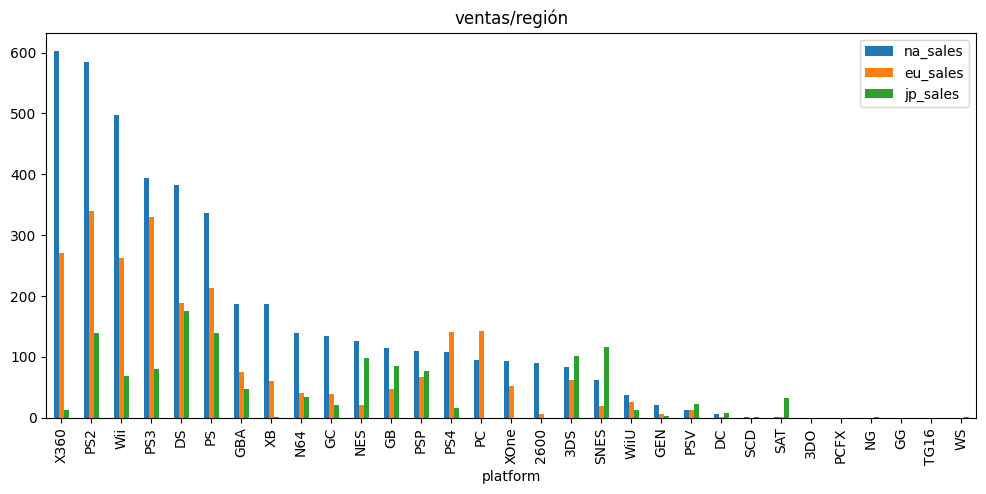

In [21]:
df_ice_na = df_ice.groupby('platform')['na_sales'].sum().reset_index().sort_values(by='na_sales', ascending=False)
print('Estas son las 5 plataformas líderes en Norte América: \n', df_ice_na.head())
df_ice_eu = df_ice.groupby('platform')['eu_sales'].sum().reset_index().sort_values(by='eu_sales', ascending=False)
print('Estas son las 5 plataformas líderes en Europa: \n', df_ice_eu.head())
df_ice_jp = df_ice.groupby('platform')['jp_sales'].sum().reset_index().sort_values(by='jp_sales', ascending=False)
print('Estas son las 5 plataformas líderes en Japón: \n', df_ice_jp.head())
df_merge_2 = df_ice_na.merge(df_ice_eu, on='platform')
df_merge_2 = df_merge_2.merge(df_ice_jp, on='platform')
df_merge_2.plot(kind='bar', title='ventas/región', figsize=[12, 5], x='platform')

Obteniendo el top 5 de plataformas por región encontramos que tanto para Europa como Norte América las plataformas con mas ventas son practicamente las mismas y son las plataformas mas actuales con excepcion de PS2 y en japón encontramos platformas mas antiguas como el caso de SNES y 3DS este es un dato importante a tener en cuenta. Y hablando de las ventas como tal Norte América esta muy por encima a las otras dos regiones.

Estos son los 5 géneros líderes en Norte América: 
        genre  na_sales
0     Action    879.01
10    Sports    684.43
8    Shooter    592.24
4   Platform    445.50
3       Misc    407.27
Estos son los 5 géneros líderes en Europa: 
       genre  eu_sales
0    Action    519.13
10   Sports    376.79
8   Shooter    317.34
6    Racing    236.51
3      Misc    212.74
Estos son los 5 géneros líderes en Japón: 
            genre  jp_sales
7   Role-Playing    355.41
0         Action    161.43
10        Sports    135.54
4       Platform    130.83
3           Misc    108.11


<Axes: title={'center': 'generos/región'}, xlabel='genre'>

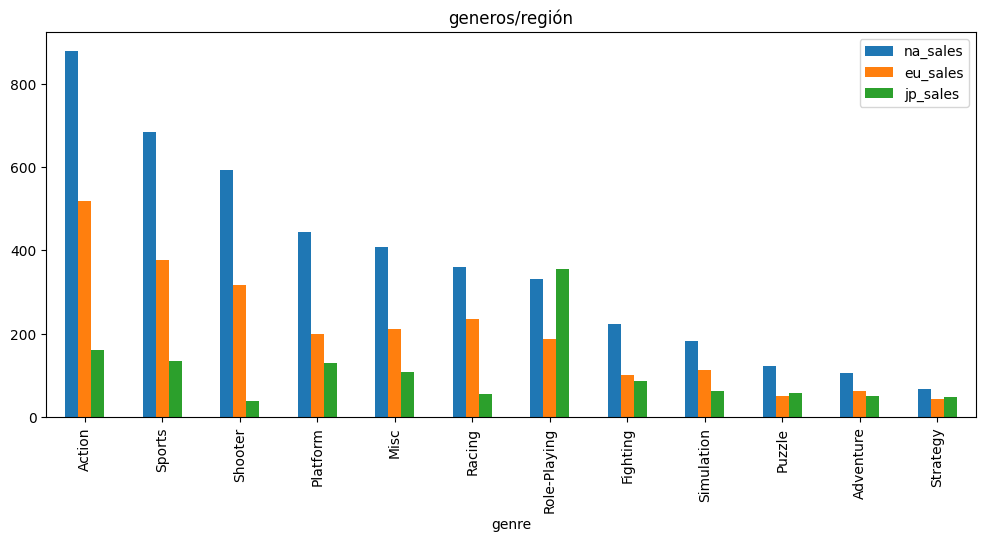

In [22]:
df_ice_genre_na = df_ice.groupby('genre')['na_sales'].sum().reset_index().sort_values(by='na_sales', ascending=False)
print('Estos son los 5 géneros líderes en Norte América: \n', df_ice_genre_na.head())
df_ice_genre_eu = df_ice.groupby('genre')['eu_sales'].sum().reset_index().sort_values(by='eu_sales', ascending=False)
print('Estos son los 5 géneros líderes en Europa: \n', df_ice_genre_eu.head())
df_ice_genre_jp = df_ice.groupby('genre')['jp_sales'].sum().reset_index().sort_values(by='jp_sales', ascending=False)
print('Estos son los 5 géneros líderes en Japón: \n', df_ice_genre_jp.head())
df_merge_3 = df_ice_genre_na.merge(df_ice_genre_eu, on='genre')
df_merge_3 = df_merge_3.merge(df_ice_genre_jp, on='genre')
df_merge_3.plot(kind='bar', title='generos/región', figsize=[12, 5], x='genre')


Elaborando un top 5 para cada región por género; aquí si que hay una similitud entre las tres regiones en cuanto a los géneros mas vendidos ya que los genro de acción, deportes, disparos y juegos de rol son los mas vendidos pero el patrón en cuanto a números isgue siendo el mismo norte américa es mucho mas rentable que el reto d elas dos regiónes.

Este es el orden de acuerdo al rating en Norte América: 
   rating  na_sales
1      E   1292.99
8    TBD   1242.46
7      T    759.75
5      M    748.48
2   E10+    353.32
Este es el orden de acuerdo al rating en Europa: 
   rating  eu_sales
1      E    710.25
8    TBD    613.83
5      M    483.97
7      T    427.03
2   E10+    188.52
Este es el orden de acuerdo al rating en Japón: 
   rating  jp_sales
8    TBD    841.96
1      E    198.11
7      T    151.40
5      M     64.24
2   E10+     40.20


<Axes: title={'center': 'rating/región'}, xlabel='rating'>

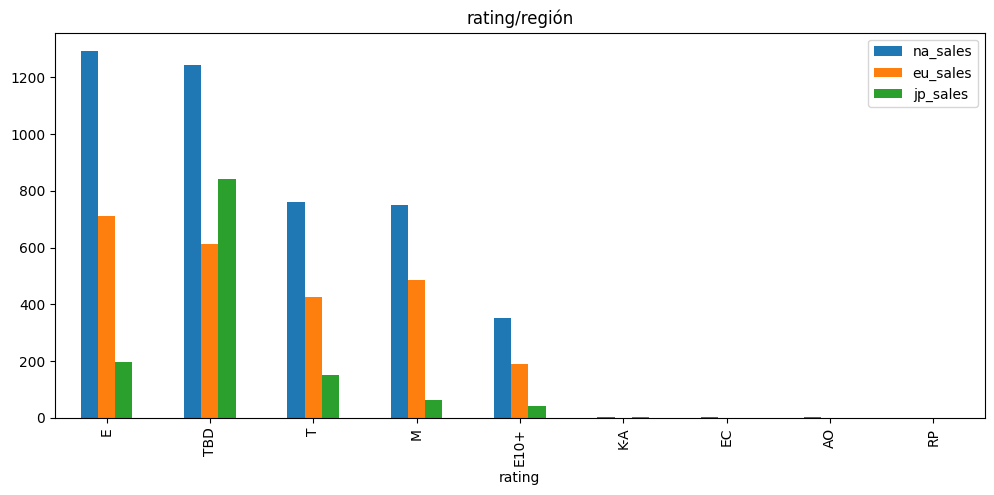

In [23]:
df_ice_rating_na = df_ice.groupby('rating')['na_sales'].sum().reset_index().sort_values(by='na_sales', ascending=False)
print('Este es el orden de acuerdo al rating en Norte América: \n', df_ice_rating_na.head())
df_ice_rating_eu = df_ice.groupby('rating')['eu_sales'].sum().reset_index().sort_values(by='eu_sales', ascending=False)
print('Este es el orden de acuerdo al rating en Europa: \n', df_ice_rating_eu.head())
df_ice_rating_jp = df_ice.groupby('rating')['jp_sales'].sum().reset_index().sort_values(by='jp_sales', ascending=False)
print('Este es el orden de acuerdo al rating en Japón: \n', df_ice_rating_jp.head())
df_merge_4 = df_ice_rating_na.merge(df_ice_rating_eu, on='rating')
df_merge_4 = df_merge_4.merge(df_ice_rating_jp, on='rating')
df_merge_4.plot(kind='bar', title='rating/región', figsize=[12, 5], x='rating')

Al finalizar con este análisis por regiones tanto para las plataformas, generos y rating podemos concluir que el perfil de usuarios de manera general para cada región podría ser asÍ:

Norte América: La platafroma más popular es X360, el género mas rentable son los juegos de acción y el rating predominate es E

Europa: La plataforma líder es PS2 junto con PS3, el género que genra más ventas es ación y el rating es también E

Japón: La mejor plataforma es la DS, el género mas rentable son los juegos de rol, y para el rating recordemos que las plataformas maspopulares y juegos son aquellos mas viejos por lo que muchso de esos juegos no tien clasificación pero en segundo lugar tambén se encuantra los tipo E.

## 7. PRUEBAS DE HIPOTESIS SCORES POR USUARIO PC VS XBOX Y ACCION VS DEEPORTES

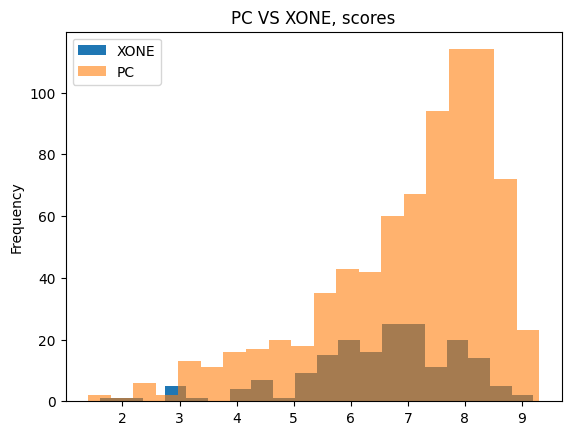

In [24]:
df_pc_vs_xone_1 = df_ice[(df_ice['platform'] == 'XOne')].copy()
df_pc_vs_xone_1['user_score'] = pd.to_numeric(df_pc_vs_xone_1['user_score'], errors='coerce')
df_pc_vs_xone_2 = df_ice[(df_ice['platform'] == 'PC')].copy()
df_pc_vs_xone_2['user_score'] = pd.to_numeric(df_pc_vs_xone_2['user_score'], errors='coerce')
df_pc_vs_xone_1['user_score'].plot(kind='hist', bins=20, alpha=1, title='PC VS XONE, scores')
df_pc_vs_xone_2['user_score'].plot(kind='hist', bins=20, alpha=0.6)
plt.legend(['XONE', 'PC'])

Se realizó un histograma general de las calificaciones por usuarios pc vs xone a continuación se formula la siguiente hipótesis:
Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas. Observando el histograma sería conveniente hacer una prueba de hipótesis de dos colas.
Hipótesis nula = las calificaciones promedio de XONE y PC son las mismas
Hipótesis alternativa = las calificaciones promedio NO son las mismas par XONE y PC

In [25]:
df_pc_vs_xone_1_total = df_pc_vs_xone_1['user_score'].dropna()
df_pc_vs_xone_2_total = df_pc_vs_xone_2['user_score'].dropna()
variance_proof_1 = st.levene(df_pc_vs_xone_1_total, df_pc_vs_xone_2_total)
print('Resultado de pruebas de varianza= ', variance_proof_1)
alpha = 0.05
results_1 = st.ttest_ind(df_pc_vs_xone_1_total, df_pc_vs_xone_2_total, equal_var=True)
print('valor p:', results_1.pvalue)
if results_1.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Resultado de pruebas de varianza=  LeveneResult(statistic=np.float64(1.2212506384014863), pvalue=np.float64(0.2693951512047048))
valor p: 1.3896435533548819e-05
Rechazamos la hipótesis nula


Con este resultado la hipótesis nula nso arroja que es rechazada por lo tanto los pormedio de las claificaciones por usuarios entre las plataformas PC y XONE no son las mismas.

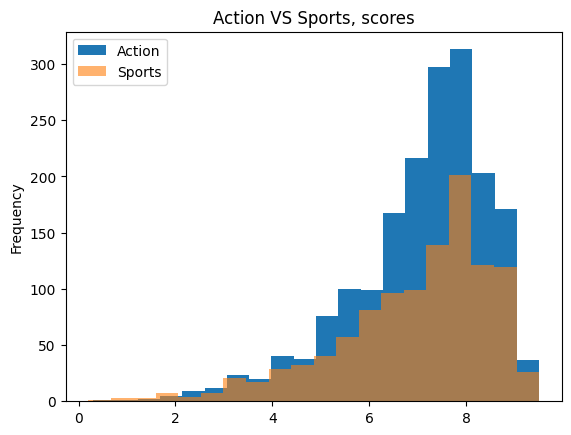

In [26]:
df_action_vs_sports_1 = df_ice[(df_ice['genre'] == 'Action')]
df_action_vs_sports_2 = df_ice[(df_ice['genre'] == 'Sports')]
df_action_vs_sports_1 = pd.to_numeric(df_action_vs_sports_1['user_score'], errors='coerce').reset_index()
df_action_vs_sports_2 = pd.to_numeric(df_action_vs_sports_2['user_score'], errors='coerce').reset_index()
df_action_vs_sports_1['user_score'].plot(kind='hist', bins=20, alpha=1, title='Action VS Sports, scores')
df_action_vs_sports_2['user_score'].plot(kind='hist', bins=20, alpha=0.6)
plt.legend(['Action', 'Sports'])

In [27]:
df_action_vs_sports_1_total = df_action_vs_sports_1['user_score'].dropna()
df_action_vs_sports_2_total = df_action_vs_sports_2['user_score'].dropna()
variance_proof_2 = st.levene(df_action_vs_sports_1_total, df_action_vs_sports_2_total)
print('Resultado de pruebas de varianza= ', variance_proof_2)
alpha = 0.05
results_2 = st.ttest_ind(df_action_vs_sports_1_total, df_action_vs_sports_2_total, equal_var=False)
print('valor p:', results_2.pvalue)
if results_2.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


Resultado de pruebas de varianza=  LeveneResult(statistic=np.float64(14.132896085177192), pvalue=np.float64(0.0001736640672727649))
valor p: 0.11483818791498288
No podemos rechazar la hipótesis nula


También se analizó lascalificaciones promedio entre lso dos génros más populares Action y Sports donde también se rechaza la hipótesis nula dejando ver que las claificaciones promedio no sonlas mismas de un género a otro estos resultados no son extraños ya que al inicio del análisis encontramos que había muchos vlaores ausentes.

## 8. CONCLUSIONES

La tienda online Ice dedicada a vender video juegos planea una campaña para el año 2017, basándose en datos proporcionados hasta el año 2016. La información dada contenía nombre, plataforma, año de lanzamiento, ventas en distintas regiones calificaciones del juego y su clasificación según la ESRB.
Lo primero que se hizo fue depurar el dataset mediante la búsqueda de valores duplicados y valores ausentes en los cuales ser rellenaron con la median para los casos de critic_score y user_score y con TBD para el rating.
Una vez realizados esos pasos se comenzó con el análisis el cual arroja lo siguiente:
1) La mayor cantidad de lanzamientos se dieron entre los años 2006 y 2011.
2) Las 5 plataformas con mas ventas a lo largo de los años que hay en el registro (1980-2016) son: PS2, X360, PS3, Wii y DS.
3) Plataformas como NES, GB, SNES, N64, durante las décadas de los 80 y 90 fueron populares y con grandes ventas, pero hoy ya no lo son o ya no existen incluso algunas.
4) La plataforma PC es la plataforma que sin duda alguna ha sido el bastión a lo largo de los años aunque sus ventas no compiten con otras plataformas si que se ha mantenido vigente a lo largo d ellos 36 años (1980-2016)
5) De las plataformas más populares en la actualidad la que tiene mayor promedio de ventas es XONE.
6) Se hizó una inspección acerca de la correlación entre las ventas y las calificaciones tanto por crítica como por usuarios; la plataforma elegida fue XONE (algo obvio al ser una de las más populares y rentables en la actualidad) y se descarta que exista una correlación entre las ventas y las calificaciones.
7) Al hacer un análisis de las ventas por región se encontró que el perfil general es:
Norte América: La plataforma más popular es X360, el género más rentable son los juegos de acción y el rating predomínate es E
Europa: La plataforma líder es PS2 junto con PS3, el género que genera más ventas es acción y el rating es también E
Japón: La mejor plataforma es la DS, el género más rentable son los juegos de rol, y para el rating recordemos que las plataformas más populares y juegos son aquellos más viejos por lo que muchos de esos juegos no tienen clasificación, pero en segundo lugar también se encuentra los tipos E.
8) Y por último no se encontró que las calificaciones promedio por usuarios sean las mismas entre las plataformas XONE y PC, la primera la más popular y rentable y PC la que se ha mantenido vigente desde los 80´s; así como tampoco se encontró  que dichas calificaciones sean las mismas entre los géneros de acción y deportes (son los que mas ventas reportan).
